# Respuesta binaria y categórica con dos o más grupos

**Curso:** Análisis de Datos e Inferencia Estadística  
**Dataset:** GRD 2023 (muestra de diagnósticos y procedimientos)  
**Propósito:** aplicar pruebas estadísticas para variables respuesta binarias y categóricas en tablas de contingencia reales.


## Objetivos de aprendizaje

Al finalizar este notebook, el estudiantado debería poder:

1. **Identificar el tipo de variable respuesta**: binaria o categórica.
2. **Reconocer cuántos grupos se comparan**: 2 grupos o 3+ grupos.
3. **Elegir la prueba adecuada** para tablas de contingencia:
   - **2x2**: prueba **chi-cuadrado** o **z de dos proporciones**.
   - **2xk** o **rxc**: prueba **chi-cuadrado de independencia**.
   - **Fisher exacta**: cuando hay frecuencias esperadas muy pequeñas en una tabla 2x2.
4. **Interpretar resultados** usando:
   - tabla de contingencia,
   - proporciones,
   - valor p,
   - tamaño de efecto (**V de Cramér**),
   - y, cuando corresponde, comparaciones post hoc.

> **Idea clave:** en este notebook trabajaremos con **variables categóricas**. No compararemos medias; compararemos **proporciones** y **distribuciones**.


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:

def fmt_p(p):
    if p < 1e-16:
        return "< 1e-16"
    return f"{p:.4g}"

def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, c = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

def standardized_residuals(table):
    chi2, p, dof, expected = chi2_contingency(table)
    obs = table.to_numpy()
    resid = (obs - expected) / np.sqrt(expected)
    return pd.DataFrame(resid, index=table.index, columns=table.columns)

def show_bar_proportions(series, title, ylabel="Proporción (%)", rotation=0):
    ax = (series * 100).plot(kind="bar", figsize=(7, 4))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

def heatmap_residuals(df_resid, title):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(df_resid.values, aspect='auto')
    ax.set_xticks(np.arange(df_resid.shape[1]))
    ax.set_yticks(np.arange(df_resid.shape[0]))
    ax.set_xticklabels(df_resid.columns, rotation=30, ha='right')
    ax.set_yticklabels(df_resid.index)
    ax.set_title(title)
    for i in range(df_resid.shape[0]):
        for j in range(df_resid.shape[1]):
            ax.text(j, i, f"{df_resid.iloc[i, j]:.2f}",
                    ha="center", va="center", fontsize=10)
    cbar = plt.colorbar(im)
    cbar.set_label("Residuo estandarizado")
    plt.tight_layout()
    plt.show()

def interpret_cramers_v(v):
    # Regla orientativa sencilla para clase
    if v < 0.10:
        return "muy pequeño / débil"
    elif v < 0.30:
        return "pequeño a moderado"
    elif v < 0.50:
        return "moderado"
    else:
        return "grande"



## Variables que usaremos

Desde el archivo GRD utilizaremos estas variables:

- **SEXO**: HOMBRE / MUJER
- **TIPO_INGRESO**: URGENCIA / PROGRAMADA / OBSTETRICA
- **TIPOALTA**: resultado del egreso hospitalario

A partir de ellas construiremos:

- **fallecido**: variable binaria  
  - 1 = `TIPOALTA == "FALLECIDO"`
  - 0 = cualquier otro tipo de alta
- **tipoalta_simple**: versión resumida de `TIPOALTA` con 5 categorías:
  - Domicilio
  - Fallecido
  - Hospitalización domiciliaria
  - Derivación
  - Otras

Estas elecciones permiten enseñar muy bien cuatro escenarios frecuentes:

1. **Respuesta binaria + 2 grupos**
2. **Respuesta binaria + 3 grupos**
3. **Respuesta categórica + 2 grupos**
4. **Respuesta categórica + 3 grupos**


In [3]:

# Buscar automáticamente el archivo ZIP en la carpeta actual
candidate_files = list(Path(".").glob("GRD_2023_muestra_diagnosticos_procedimientos*.zip"))
if not candidate_files:
    raise FileNotFoundError("No encontré el archivo ZIP del GRD en la carpeta actual.")

zip_path = candidate_files[0]
csv_name = None
with ZipFile(zip_path) as z:
    for name in z.namelist():
        if name.endswith(".csv"):
            csv_name = name
            break

if csv_name is None:
    raise FileNotFoundError("No encontré un archivo CSV dentro del ZIP.")

usecols = ["SEXO", "TIPO_INGRESO", "TIPOALTA"]

with ZipFile(zip_path) as z:
    with z.open(csv_name) as f:
        df = pd.read_csv(f, usecols=usecols, low_memory=False)

print(f"Archivo leído: {zip_path.name}")
print(f"CSV interno: {csv_name}")
print(f"Filas y columnas originales: {df.shape}")
df.head()


Archivo leído: GRD_2023_muestra_diagnosticos_procedimientos (1).zip
CSV interno: GRD_2023_muestra_diagnosticos_procedimientos.csv
Filas y columnas originales: (1039587, 3)


,SEXO,TIPO_INGRESO,TIPOALTA
0,HOMBRE,URGENCIA,DOMICILIO
1,HOMBRE,URGENCIA,DOMICILIO
2,HOMBRE,URGENCIA,HOSPITALIZACIÓN DOMICILIARIA
3,MUJER,PROGRAMADA,DOMICILIO
4,MUJER,URGENCIA,DOMICILIO


In [4]:

# Limpieza mínima y creación de variables analíticas
df = df.copy()

# Nos quedamos con categorías claras para clase
df = df[df["SEXO"].isin(["HOMBRE", "MUJER"])]
df = df[df["TIPO_INGRESO"].isin(["URGENCIA", "PROGRAMADA", "OBSTETRICA"])]
df = df[df["TIPOALTA"].notna()].copy()

# Variable respuesta binaria
df["fallecido"] = (df["TIPOALTA"] == "FALLECIDO").astype(int)

# Variable respuesta categórica resumida
def simplificar_tipo_alta(x):
    if x == "DOMICILIO":
        return "Domicilio"
    if x == "FALLECIDO":
        return "Fallecido"
    if x == "HOSPITALIZACIÓN DOMICILIARIA":
        return "Hosp. domiciliaria"
    if "DERIVACIÓN" in str(x):
        return "Derivación"
    return "Otras"

df["tipoalta_simple"] = df["TIPOALTA"].map(simplificar_tipo_alta)

print(f"Filas luego de limpieza: {df.shape[0]:,}")
print("\\nFrecuencia de SEXO")
display(df["SEXO"].value_counts())

print("\\nFrecuencia de TIPO_INGRESO")
display(df["TIPO_INGRESO"].value_counts())

print("\\nFrecuencia de tipoalta_simple")
display(df["tipoalta_simple"].value_counts())


Filas luego de limpieza: 1,039,493
\nFrecuencia de SEXO


SEXO
MUJER     612178
HOMBRE    427315
Name: count, dtype: int64

\nFrecuencia de TIPO_INGRESO


TIPO_INGRESO
URGENCIA      518603
PROGRAMADA    366363
OBSTETRICA    154527
Name: count, dtype: int64

\nFrecuencia de tipoalta_simple


tipoalta_simple
Domicilio             936117
Derivación             35404
Hosp. domiciliaria     29298
Fallecido              25133
Otras                  13541
Name: count, dtype: int64


## Regla práctica para elegir la prueba

### Caso A. Respuesta binaria y 2 grupos
Ejemplo: fallecido (sí/no) según sexo (hombre/mujer).

- Tabla: **2x2**
- Prueba recomendada:
  - **Chi-cuadrado**
  - o **z de dos proporciones** (equivalente para este contexto)
- Si hay frecuencias esperadas muy pequeñas: **Fisher exacta**

### Caso B. Respuesta binaria y 3 o más grupos
Ejemplo: fallecido (sí/no) según tipo de ingreso.

- Tabla: **2xk**
- Prueba recomendada: **chi-cuadrado de independencia**
- Si el resultado global es significativo, conviene explorar **qué grupos difieren** con comparaciones post hoc.

### Caso C. Respuesta categórica con 3 o más categorías
Ejemplo: tipo de alta resumido según sexo o tipo de ingreso.

- Tabla: **rxc**
- Prueba recomendada: **chi-cuadrado de independencia**
- Para interpretar **qué celdas explican la asociación**, son muy útiles los **residuos estandarizados**.

### Recordatorio sobre hipótesis

- **H₀**: la variable respuesta es independiente del grupo
- **H₁**: hay asociación entre la variable respuesta y el grupo



# 1) Respuesta binaria con 2 grupos

## Pregunta
**¿La proporción de egresos por fallecimiento difiere entre hombres y mujeres?**

- **Respuesta**: `fallecido` (sí/no)
- **Grupo**: `SEXO` (HOMBRE / MUJER)

La tabla es **2x2**, por lo que podemos usar:

- **chi-cuadrado**
- **z de dos proporciones**
- **Fisher exacta** si hiciera falta (aquí no será necesario, porque las frecuencias son muy grandes).


In [5]:

tab1 = pd.crosstab(df["SEXO"], df["fallecido"])
tab1.columns = ["No fallecido", "Fallecido"]
print("Tabla de contingencia (conteos):")
display(tab1)

tab1_prop = tab1.div(tab1.sum(axis=1), axis=0)
print("Tabla de contingencia (proporciones por fila):")
display((tab1_prop * 100).round(2))


Tabla de contingencia (conteos):


,No fallecido,Fallecido
SEXO,,
HOMBRE,413702,13613
MUJER,600658,11520


Tabla de contingencia (proporciones por fila):


,No fallecido,Fallecido
SEXO,,
HOMBRE,96.8100,3.1900
MUJER,98.1200,1.8800


In [6]:

# Chi-cuadrado
chi2_1, p_1, dof_1, exp_1 = chi2_contingency(tab1)

# z de dos proporciones
counts = tab1["Fallecido"].values
nobs = tab1.sum(axis=1).values
z_1, pz_1 = proportions_ztest(counts, nobs)

# Diferencia absoluta de proporciones e IC95% (aprox. Wald, suficiente para este notebook)
p_hombres = counts[0] / nobs[0]
p_mujeres = counts[1] / nobs[1]
diff = p_hombres - p_mujeres
se_diff = np.sqrt(p_hombres * (1 - p_hombres) / nobs[0] + p_mujeres * (1 - p_mujeres) / nobs[1])
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

# Odds ratio con IC95%
a = tab1.loc["HOMBRE", "Fallecido"]
b = tab1.loc["HOMBRE", "No fallecido"]
c = tab1.loc["MUJER", "Fallecido"]
d = tab1.loc["MUJER", "No fallecido"]
odds_ratio = (a / b) / (c / d)
se_log_or = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
or_low = np.exp(np.log(odds_ratio) - 1.96 * se_log_or)
or_high = np.exp(np.log(odds_ratio) + 1.96 * se_log_or)

print("Resultados principales")
print(f"- Proporción de fallecidos en hombres: {p_hombres*100:.2f}%")
print(f"- Proporción de fallecidos en mujeres: {p_mujeres*100:.2f}%")
print(f"- Diferencia absoluta: {diff*100:.2f} puntos porcentuales")
print(f"- IC95% de la diferencia: [{ci_low*100:.2f}, {ci_high*100:.2f}] pp")
print(f"- Chi-cuadrado = {chi2_1:,.2f}, gl = {dof_1}, p {fmt_p(p_1)}")
print(f"- z de dos proporciones = {z_1:,.2f}, p {fmt_p(pz_1)}")
print(f"- Odds ratio = {odds_ratio:.3f} (IC95%: {or_low:.3f} a {or_high:.3f})")
print(f"- V de Cramér = {cramers_v(tab1):.3f} -> efecto {interpret_cramers_v(cramers_v(tab1))}")


Resultados principales
- Proporción de fallecidos en hombres: 3.19%
- Proporción de fallecidos en mujeres: 1.88%
- Diferencia absoluta: 1.30 puntos porcentuales
- IC95% de la diferencia: [1.24, 1.37] pp
- Chi-cuadrado = 1,812.87, gl = 1, p < 1e-16
- z de dos proporciones = 42.58, p < 1e-16
- Odds ratio = 1.716 (IC95%: 1.673 a 1.759)
- V de Cramér = 0.042 -> efecto muy pequeño / débil


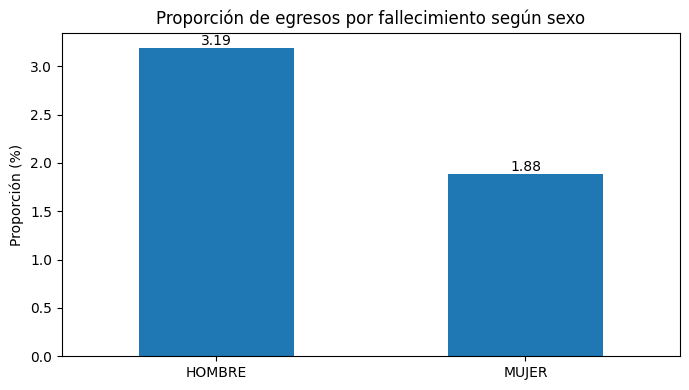

In [7]:

show_bar_proportions(
    tab1_prop["Fallecido"],
    "Proporción de egresos por fallecimiento según sexo"
)



### Interpretación docente sugerida

- El valor p es extremadamente pequeño, por lo que **rechazamos H₀**.
- Hay evidencia de que la proporción de egresos por fallecimiento **no es igual** entre hombres y mujeres.
- Pero además del valor p debemos mirar el **tamaño de efecto**:
  - aquí el **V de Cramér es pequeño**, así que la asociación existe, pero no es enorme.
- Esto es una muy buena oportunidad para enseñar que:
  - con muestras gigantes, incluso diferencias pequeñas pueden resultar muy significativas.



# 2) Respuesta binaria con 3 grupos

## Pregunta
**¿La proporción de egresos por fallecimiento difiere según el tipo de ingreso?**

- **Respuesta**: `fallecido` (sí/no)
- **Grupo**: `TIPO_INGRESO` (URGENCIA / PROGRAMADA / OBSTETRICA)

La tabla ahora es **2x3**, así que usamos **chi-cuadrado de independencia** como prueba global.
Luego, si el resultado es significativo, hacemos comparaciones post hoc entre pares de grupos.


In [8]:

tab2 = pd.crosstab(df["TIPO_INGRESO"], df["fallecido"])
tab2.columns = ["No fallecido", "Fallecido"]
print("Tabla de contingencia (conteos):")
display(tab2)

tab2_prop = tab2.div(tab2.sum(axis=1), axis=0)
print("Proporción de fallecidos por tipo de ingreso:")
display((tab2_prop[["Fallecido"]] * 100).round(3))


Tabla de contingencia (conteos):


,No fallecido,Fallecido
TIPO_INGRESO,,
OBSTETRICA,154508,19
PROGRAMADA,365582,781
URGENCIA,494270,24333


Proporción de fallecidos por tipo de ingreso:


,Fallecido
TIPO_INGRESO,
OBSTETRICA,0.0120
PROGRAMADA,0.2130
URGENCIA,4.6920


In [9]:

chi2_2, p_2, dof_2, exp_2 = chi2_contingency(tab2)

print("Prueba global")
print(f"- Chi-cuadrado = {chi2_2:,.2f}, gl = {dof_2}, p {fmt_p(p_2)}")
print(f"- V de Cramér = {cramers_v(tab2):.3f} -> efecto {interpret_cramers_v(cramers_v(tab2))}")

# Comparaciones post hoc: z de dos proporciones entre pares
from itertools import combinations

rows = []
for g1, g2 in combinations(tab2.index, 2):
    c1 = tab2.loc[g1, "Fallecido"]
    n1 = tab2.loc[g1].sum()
    c2 = tab2.loc[g2, "Fallecido"]
    n2 = tab2.loc[g2].sum()

    z, p = proportions_ztest([c1, c2], [n1, n2])

    p1 = c1 / n1
    p2 = c2 / n2
    diff = p1 - p2
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    ci_low = diff - 1.96 * se
    ci_high = diff + 1.96 * se

    rows.append({
        "Grupo 1": g1,
        "Grupo 2": g2,
        "Prop. Grupo 1 (%)": p1 * 100,
        "Prop. Grupo 2 (%)": p2 * 100,
        "Diferencia (pp)": diff * 100,
        "z": z,
        "p sin ajuste": p,
        "IC95% inf (pp)": ci_low * 100,
        "IC95% sup (pp)": ci_high * 100,
    })

posthoc2 = pd.DataFrame(rows)
posthoc2["p ajustado Holm"] = multipletests(posthoc2["p sin ajuste"], method="holm")[1]
display(posthoc2.round(4))


Prueba global
- Chi-cuadrado = 22,705.76, gl = 2, p < 1e-16
- V de Cramér = 0.148 -> efecto pequeño a moderado


,Grupo 1,Grupo 2,Prop. Grupo 1 (%),Prop. Grupo 2 (%),Diferencia (pp),z,p sin ajuste,IC95% inf (pp),IC95% sup (pp),p ajustado Holm
0,OBSTETRICA,PROGRAMADA,0.0123,0.2132,-0.2009,-16.9116,0.0000,-0.2168,-0.1850,0.0000
1,OBSTETRICA,URGENCIA,0.0123,4.6920,-4.6797,-86.4719,0.0000,-4.7376,-4.6219,0.0000
2,PROGRAMADA,URGENCIA,0.2132,4.6920,-4.4789,-124.9780,0.0000,-4.5383,-4.4194,0.0000


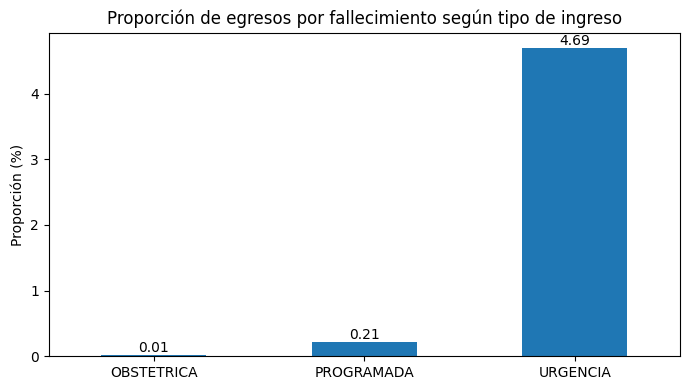

In [10]:

show_bar_proportions(
    tab2_prop["Fallecido"],
    "Proporción de egresos por fallecimiento según tipo de ingreso"
)



### Interpretación docente sugerida

- La prueba global indica que la mortalidad hospitalaria **varía según el tipo de ingreso**.
- Después del resultado global, las comparaciones post hoc permiten ver **qué pares de grupos** difieren.
- En este dataset, el patrón esperado es muy marcado:
  - ingresos por **urgencia** muestran una proporción de fallecimiento mucho mayor,
  - los ingresos **obstétricos** muestran una proporción muy baja.
- Aquí el **V de Cramér** ya no es tan pequeño como en el ejemplo anterior, lo que sugiere una asociación más relevante.



# 3) Respuesta categórica con 2 grupos

## Pregunta
**¿La distribución del tipo de alta resumido difiere entre hombres y mujeres?**

- **Respuesta**: `tipoalta_simple` (5 categorías)
- **Grupo**: `SEXO` (2 grupos)

La tabla es **2x5**. Aquí usamos **chi-cuadrado de independencia**.
Como la respuesta tiene varias categorías, ayuda mucho mirar también los **residuos estandarizados**.


In [11]:

tab3 = pd.crosstab(df["SEXO"], df["tipoalta_simple"])
print("Tabla de contingencia (conteos):")
display(tab3)

print("Proporciones por fila (%):")
display((tab3.div(tab3.sum(axis=1), axis=0) * 100).round(2))


Tabla de contingencia (conteos):


tipoalta_simple,Derivación,Domicilio,Fallecido,Hosp. domiciliaria,Otras
SEXO,,,,,
HOMBRE,19213,374031,13613,13677,6781
MUJER,16191,562086,11520,15621,6760


Proporciones por fila (%):


tipoalta_simple,Derivación,Domicilio,Fallecido,Hosp. domiciliaria,Otras
SEXO,,,,,
HOMBRE,4.5000,87.5300,3.1900,3.2000,1.5900
MUJER,2.6400,91.8200,1.8800,2.5500,1.1000


In [12]:

chi2_3, p_3, dof_3, exp_3 = chi2_contingency(tab3)
resid3 = standardized_residuals(tab3)

print("Resultados")
print(f"- Chi-cuadrado = {chi2_3:,.2f}, gl = {dof_3}, p {fmt_p(p_3)}")
print(f"- V de Cramér = {cramers_v(tab3):.3f} -> efecto {interpret_cramers_v(cramers_v(tab3))}")

print("\\nResiduos estandarizados")
display(resid3.round(2))


Resultados
- Chi-cuadrado = 5,641.80, gl = 4, p < 1e-16
- V de Cramér = 0.074 -> efecto muy pequeño / débil
\nResiduos estandarizados


tipoalta_simple,Derivación,Domicilio,Fallecido,Hosp. domiciliaria,Otras
SEXO,,,,,
HOMBRE,38.6200,-17.3900,32.2800,14.8800,16.2800
MUJER,-32.2700,14.5300,-26.9700,-12.4300,-13.6000


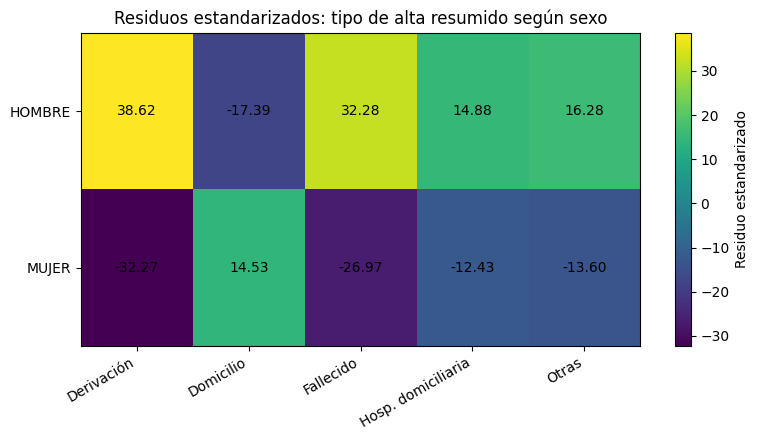

In [13]:

heatmap_residuals(
    resid3,
    "Residuos estandarizados: tipo de alta resumido según sexo"
)



### Cómo leer los residuos estandarizados

- Un residuo estandarizado cercano a **0** indica que la celda observada es parecida a la esperada bajo H₀.
- Valores grandes en magnitud (por ejemplo, **>|2|**) sugieren que esa celda contribuye fuertemente al chi-cuadrado.
- Residuo **positivo**: hubo **más casos observados** que los esperados.
- Residuo **negativo**: hubo **menos casos observados** que los esperados.

En clases, esta tabla suele ser muy útil para pasar de  
“**hay asociación**”  
a  
“**¿dónde está exactamente esa asociación?**”.



# 4) Respuesta categórica con 3 grupos

## Pregunta
**¿La distribución del tipo de alta resumido difiere según el tipo de ingreso?**

- **Respuesta**: `tipoalta_simple` (5 categorías)
- **Grupo**: `TIPO_INGRESO` (3 grupos)

La tabla es **3x5**, por lo que usamos nuevamente **chi-cuadrado de independencia**.


In [14]:

tab4 = pd.crosstab(df["TIPO_INGRESO"], df["tipoalta_simple"])
print("Tabla de contingencia (conteos):")
display(tab4)

print("Proporciones por fila (%):")
display((tab4.div(tab4.sum(axis=1), axis=0) * 100).round(2))


Tabla de contingencia (conteos):


tipoalta_simple,Derivación,Domicilio,Fallecido,Hosp. domiciliaria,Otras
TIPO_INGRESO,,,,,
OBSTETRICA,2011,149680,19,351,2466
PROGRAMADA,2960,359294,781,2643,685
URGENCIA,30433,427143,24333,26304,10390


Proporciones por fila (%):


tipoalta_simple,Derivación,Domicilio,Fallecido,Hosp. domiciliaria,Otras
TIPO_INGRESO,,,,,
OBSTETRICA,1.3000,96.8600,0.0100,0.2300,1.6000
PROGRAMADA,0.8100,98.0700,0.2100,0.7200,0.1900
URGENCIA,5.8700,82.3600,4.6900,5.0700,2.0000


In [15]:

chi2_4, p_4, dof_4, exp_4 = chi2_contingency(tab4)
resid4 = standardized_residuals(tab4)

print("Resultados")
print(f"- Chi-cuadrado = {chi2_4:,.2f}, gl = {dof_4}, p {fmt_p(p_4)}")
print(f"- V de Cramér = {cramers_v(tab4):.3f} -> efecto {interpret_cramers_v(cramers_v(tab4))}")

print("\\nResiduos estandarizados")
display(resid4.round(2))


Resultados
- Chi-cuadrado = 71,774.83, gl = 8, p < 1e-16
- V de Cramér = 0.186 -> efecto pequeño a moderado
\nResiduos estandarizados


tipoalta_simple,Derivación,Domicilio,Fallecido,Hosp. domiciliaria,Otras
TIPO_INGRESO,,,,,
OBSTETRICA,-44.8300,28.2000,-60.8100,-60.6800,10.1000
PROGRAMADA,-85.2100,51.1200,-85.8200,-75.6100,-59.1700
URGENCIA,96.0900,-58.3600,105.3300,96.6700,44.2200


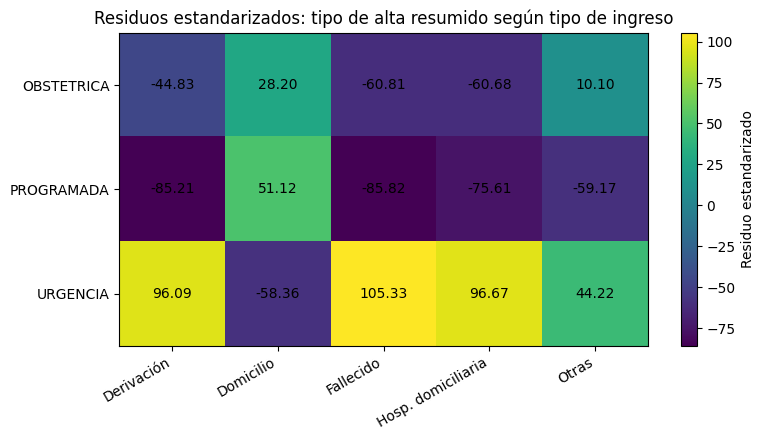

In [16]:

heatmap_residuals(
    resid4,
    "Residuos estandarizados: tipo de alta resumido según tipo de ingreso"
)



# Conclusiones finales

## Qué aprendimos con este notebook

### Cuando la respuesta es binaria
- Si hay **2 grupos**, una tabla **2x2** puede analizarse con:
  - **chi-cuadrado**
  - **z de dos proporciones**
  - **Fisher exacta** si los conteos son pequeños

- Si hay **3 o más grupos**, usamos:
  - **chi-cuadrado de independencia**
  - y luego, si es necesario, **comparaciones post hoc**

### Cuando la respuesta es categórica con varias categorías
- Usamos **chi-cuadrado de independencia**
- Miramos:
  - la tabla de proporciones,
  - el valor p,
  - el **V de Cramér**,
  - y los **residuos estandarizados**

## Mensaje metodológico importante

Un valor p pequeño **no basta** por sí solo.

Siempre conviene preguntar:

1. **¿Qué tan grande es la diferencia?**
2. **¿Es relevante en términos prácticos o clínicos?**
3. **¿Qué celdas explican la asociación?**
4. **¿La muestra es tan grande que detecta diferencias pequeñas?**

---

## Ejercicios sugeridos para el estudiantado

1. Repetir el análisis usando otra variable de grupo, por ejemplo `SERVICIO_SALUD` o `COD_HOSPITAL` (si cargan más columnas).
2. Construir una nueva variable binaria, por ejemplo:
   - `alta_domicilio = 1` si `TIPOALTA == "DOMICILIO"`, 0 en otro caso.
3. Probar un nuevo agrupamiento de `TIPOALTA`.
4. Explicar con palabras la diferencia entre:
   - **significancia estadística**
   - **tamaño de efecto**
   - **importancia práctica**

Este notebook está pensado para que el estudiantado no solo “corra una prueba”, sino que entienda **cuándo usarla y cómo interpretarla**.
